# Figures 3.3-2 and 3.3-3 &mdash; methane and nitrogen, from the Peng&ndash;Robinson equation

Figure 3.3-2 is a **pressure&ndash;enthalpy chart for methane** and Figure 3.3-3 is the same
chart for **nitrogen**. This notebook draws both of them from the **Peng&ndash;Robinson
equation of state** &mdash; the equation of Chapter 6 &mdash; and nothing else.

That is worth saying plainly, because it is unusual. A property chart normally arrives from
outside the book, measured and correlated by somebody else, and you read it on trust. These two
you can rebuild. Every curve on them comes from three inputs:

| | |
|---|---|
| $T_c$, $P_c$, $\omega$ | **Table 6.6-1**, three numbers per fluid |
| $C_P^{*}(T)$ | **Appendix A.II**, four coefficients |
| the equation itself | **Eq. 6.4-2**, plus the departure functions of &sect;6.4 |

The book already does this once, for oxygen: Illustration 6.4-1 builds the charts,
Illustration 7.5-1 adds the vapor pressure and the two coexisting phases, and Illustration 7.5-2
completes them &mdash; Table 7.5-2 is 208 of these numbers in print. What is new here is only the
drawing.

**What this notebook does**

1. settles methane's ideal-gas heat capacity, which Appendix A.II's printed row gets badly
   wrong at these temperatures &mdash; and which everything else rests on;
2. checks the equation of state against the book's own vapor-pressure constants before drawing
   anything with it;
3. builds the five families of curves a $P$&ndash;$\hat H$ chart is made of;
4. draws both charts;
5. works **Illustration 6.5-1** on the nitrogen chart, which is where the text reads it.

SIS is Stanley I. Sandler, *Chemical, Biochemical, and Engineering Thermodynamics*.

Eric Furst<br>
August 2026

In [1]:
# --- Colab bootstrap -------------------------------------------------------
# No-op when the thermo package is already alongside this notebook (the normal
# case: you cloned the repository and are running from code/ch3/). In Colab
# there is no repository, so fetch the package and the property data.
import os, sys
if not (os.path.isdir('../thermo') or os.path.isdir('thermo')):
    !git clone -q --depth 1 https://github.com/emfurst/cbet6e.git /tmp/cbet6e
    !cp -r /tmp/cbet6e/code/thermo /tmp/cbet6e/code/data .
    sys.path.insert(0, '.')
else:
    sys.path.insert(0, '..')
DATA = '../data' if os.path.isdir('../data') else 'data'
# ---------------------------------------------------------------------------


In [2]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from scipy.optimize import brentq
from scipy.constants import R
from shutil import which

from thermo import PengRobinson, APPENDIX_A2_CP_CRYO, TABLE_6_6_1

mpl.rcParams["text.usetex"] = which("latex") is not None
mpl.rcParams.update({"font.family": "serif", "mathtext.fontset": "cm",
                     "pdf.fonttype": 42, "ps.fonttype": 42})

TREF = 298.15          # K, where the ideal-gas integrals start (arbitrary, cancels)
PREF = 1e5             # Pa

## 1. Methane's ideal-gas heat capacity, and why the printed row will not do

Every enthalpy on these charts is an ideal-gas enthalpy plus a departure function, so
$C_P^{*}(T)$ sets the whole scale. For nitrogen the book already has what is needed. For
methane it does not, and the gap is the largest of its kind in the book.

Appendix A.II gives methane as $19.875 + 5.021\times10^{-2}\,T + 1.268\times10^{-5}\,T^2 -
11.004\times10^{-9}\,T^3$, **valid 273&ndash;1500 K**, and inside that range it is excellent:
35.68 J/(mol K) at 298 K. The methane chart starts at 111 K. Extrapolated down there, the same
row returns **25.0 J/(mol K)** &mdash; and that number is impossible.

**Why impossible?** A methane molecule has three ways to store energy: moving (translation),
tumbling (rotation), and its atoms vibrating against one another. At low temperature the
vibrations are frozen out &mdash; there is not enough thermal energy to excite them &mdash; and
only the first two survive. For a *nonlinear* molecule that gives

$$ C_P^{*} \;\longrightarrow\; \underbrace{\tfrac32 R}_{\text{translation}}
   + \underbrace{\tfrac32 R}_{\text{rotation}} + \underbrace{R}_{PV}
   \;=\; 4R \;=\; 33.26 \ \mathrm{J/(mol\ K)} $$

as a floor, not a value to be fitted. A.II's extrapolation goes 25 % *below* the floor.

So we compute it instead. Adding the vibrations back is one standard expression &mdash; each
normal mode contributes an Einstein term:

$$ C_P^{*}(T) = 4R + R\sum_i g_i \frac{u_i^2 e^{u_i}}{(e^{u_i}-1)^2},
   \qquad u_i = \frac{hc\tilde\nu_i}{k_BT} $$

with methane's nine modes at $\tilde\nu$ = 2917 (&times;1), 1534 (&times;2), 3019 (&times;3) and
1306 (&times;3) cm$^{-1}$. **The next cell checks that against NIST-JANAF over the range where
JANAF exists**, which is the whole basis for trusting it below that range.

In [3]:
from scipy import constants as C

# CH4's nine normal modes (3N - 6): wavenumber in cm^-1, and degeneracy.
CH4_MODES = [(2917.0, 1), (1534.0, 2), (3019.0, 3), (1306.0, 3)]


def cp_methane_statmech(T):
    """Ideal-gas Cp* of methane, J/(mol K), from its vibrational spectrum."""
    T = np.asarray(T, float)
    vib = np.zeros_like(T)
    for nu, g in CH4_MODES:
        u = C.h*C.c*100*nu/(C.k*T)
        vib += g*u**2*np.exp(u)/(np.exp(u) - 1)**2
    return 4*R + R*vib          # 4R = translation + rotation + R, the low-T floor


def cp_methane_janaf(T):
    """NIST-JANAF Shomate fit, 298-1300 K. Chase, NIST-JANAF Thermochemical Tables,
    4th ed., J. Phys. Chem. Ref. Data Monograph 9 (1998); webbook.nist.gov C74828."""
    A, B, Cc, D, E = -0.703029, 108.4773, -42.52157, 5.862788, 0.678565
    t = np.asarray(T, float)/1000
    return A + B*t + Cc*t**2 + D*t**3 + E/t**2


def cp_A2_printed(T):
    """Appendix A.II's methane row as printed, valid 273-1500 K."""
    T = np.asarray(T, float)
    return 19.875 + 5.021e-2*T + 1.268e-5*T**2 - 11.004e-9*T**3


T = np.array([298.15, 400, 500, 700, 1000, 1300])
print("where JANAF exists -- this is the check:")
print(f"{'T (K)':>8}{'derived':>10}{'JANAF':>9}{'diff':>8}")
for t in T:
    print(f"{t:8.1f}{cp_methane_statmech(t):10.3f}{cp_methane_janaf(t):9.3f}"
          f"{cp_methane_statmech(t)-cp_methane_janaf(t):+8.3f}")
print(f"\nworst disagreement over 298-1300 K: "
      f"{np.abs(cp_methane_statmech(np.linspace(298,1300,400)) - cp_methane_janaf(np.linspace(298,1300,400))).max():.3f}"
      " J/(mol K)\n")
print("below JANAF's range -- where this chart lives:")
print(f"{'T (K)':>8}{'derived':>10}{'A.II':>9}{'A.II err':>10}")
for t in (100, 120, 150, 200, 250):
    d, a = float(cp_methane_statmech(t)), float(cp_A2_printed(t))
    print(f"{t:8.1f}{d:10.3f}{a:9.3f}{100*(a-d)/d:9.1f}%")
print(f"\nthe floor, 4R = {4*R:.3f} J/(mol K)")

where JANAF exists -- this is the check:
   T (K)   derived    JANAF    diff
   298.1    35.640   35.648  -0.009
   400.0    40.500   40.501  -0.001
   500.0    46.342   46.352  -0.010
   700.0    57.794   57.791  +0.002
  1000.0    71.793   71.794  -0.001
  1300.0    81.742   81.738  +0.004

worst disagreement over 298-1300 K: 0.034 J/(mol K)

below JANAF's range -- where this chart lives:
   T (K)   derived     A.II  A.II err
   100.0    33.258   25.012    -24.8%
   120.0    33.259   26.064    -21.6%
   150.0    33.274   27.655    -16.9%
   200.0    33.474   30.336     -9.4%
   250.0    34.216   33.048     -3.4%

the floor, 4R = 33.258 J/(mol K)


The derived curve reproduces JANAF to **&plusmn;0.03 J/(mol K)** &mdash; far better than any use
here needs, and enough to say that the same expression continued below 298 K is physics rather
than an extrapolation. It arrives at 33.26 at 100 K, which is $4R$ to three decimals.

The printed row, meanwhile, is **25 % low at 100 K**. Integrated across the span this chart
covers, that is **&minus;635 J/mol in $\underline H$ and &minus;4.5 J/(mol K) in $\underline S$**
&mdash; 8 % of methane's entire heat of vaporization, which would visibly misplace every isotherm.

So the 6e adds a **cryogenic-range methane row to Appendix A.II**, in the appendix's own cubic
form and its own idiom &mdash; A.II already splits gases into temperature ranges, and the range
column does the work. The cell below is the fit, and it is the provenance for the numbers in
`thermo.APPENDIX_A2_CP_CRYO["methane"]`: if you doubt a coefficient, run this.

In [4]:
from thermo import APPENDIX_A2_CP_CRYO

FIT_RANGE = (100, 500)      # K
Tf = np.linspace(*FIT_RANGE, 2000)
coef = np.polyfit(Tf, cp_methane_statmech(Tf), 3)[::-1]

# Appendix A.II prints a, b x 10^2, c x 10^5, d x 10^9 -- and to three decimals. Round
# to what the page can print, so a reader who types the printed row in here gets these
# same curves back.
printed = (round(coef[0], 3), round(coef[1]*1e2, 3)/1e2,
           round(coef[2]*1e5, 3)/1e5, round(coef[3]*1e9, 3)/1e9)
print("Appendix A.II form:  a = %.3f   b = %+.3f   c = %+.3f   d = %+.3f   (x1, x1e2, x1e5, x1e9)"
      % (printed[0], printed[1]*1e2, printed[2]*1e5, printed[3]*1e9))
print("in thermo         : ", APPENDIX_A2_CP_CRYO["methane"])
assert np.allclose(printed, APPENDIX_A2_CP_CRYO["methane"], rtol=1e-9), \
    "the fit no longer matches the tabulated row"

cp_fit = lambda T: sum(printed[i]*np.asarray(T, float)**i for i in range(4))
Tc_span = np.linspace(100, 400, 3000)                  # the chart's own span
for label, cp in (("cryogenic row", cp_fit), ("A.II as printed", cp_A2_printed)):
    e = cp(Tc_span) - cp_methane_statmech(Tc_span)
    print(f"  {label:16s} max |dCp*| = {np.abs(e).max():6.3f}   "
          f"dH = {np.trapezoid(e, Tc_span):+8.1f} J/mol   "
          f"dS = {np.trapezoid(e/Tc_span, Tc_span):+7.3f} J/(mol K)")

Appendix A.II form:  a = 37.097   b = -5.282   c = +18.976   d = -92.669   (x1, x1e2, x1e5, x1e9)
in thermo         :  (37.097, -0.05282, 0.00018976, -9.2669e-08)
  cryogenic row    max |dCp*| =  0.362   dH =     +2.2 J/mol   dS =  +0.010 J/(mol K)
  A.II as printed  max |dCp*| =  8.246   dH =   -635.2 J/mol   dS =  -4.521 J/(mol K)


## 2. Does the equation of state earn the chart? Check it before drawing

Peng&ndash;Robinson is a cubic, and cubics are not exact. Before drawing 300 curves with one it
is worth asking what it gets right, against something independent.

`code/data/pure_property.csv` &mdash; the book's own property database &mdash; carries **Wagner
vapor-pressure constants** for both fluids. Those are a correlation of measured vapor pressures,
they have nothing to do with Peng&ndash;Robinson, and they are already ours. They make a fair
referee for the one curve everything else hangs from: the saturation line.

In [5]:
import pandas as pd
from thermo import PengRobinson, TABLE_6_6_1

PURE = pd.read_csv(f"{DATA}/pure_property.csv")


def wagner_Psat(formula, T):
    """The book's own vapor-pressure correlation (Appendix A.II, Eq. 1), in bar."""
    r = PURE[PURE.Formula == formula].iloc[0]
    t = 1 - T/r.Tc
    return r.Pc*np.exp((r.VpA*t + r.VpB*t**1.5 + r.VpC*t**3 + r.VpD*t**6)/(1 - t))

In [6]:
FLUIDS = {"methane":  dict(formula="CH4", M=16.043, T_triple=90.69),
          "nitrogen": dict(formula="N2",  M=28.013, T_triple=63.15)}

for key, spec in FLUIDS.items():
    pr = PengRobinson(**TABLE_6_6_1[key], cp=APPENDIX_A2_CP_CRYO[key])
    print(f"\n{key}:  Tc = {pr.Tc} K,  Pc = {pr.Pc/1e6:.3f} MPa,  omega = {pr.omega}")
    print(f"{'T (K)':>8}{'Tr':>7}{'Wagner (bar)':>14}{'PR (bar)':>10}{'err':>8}")
    worst = 0.0
    for Tr in (0.55, 0.65, 0.75, 0.85, 0.95):
        T = Tr*pr.Tc
        pw = float(wagner_Psat(spec["formula"], T))
        pp = pr.vapor_pressure(T)/1e5
        worst = max(worst, abs(100*(pp - pw)/pw))
        print(f"{T:8.1f}{Tr:7.2f}{pw:14.4f}{pp:10.4f}{100*(pp-pw)/pw:7.1f}%")
    print(f"  worst: {worst:.1f}%")


methane:  Tc = 190.6 K,  Pc = 4.600 MPa,  omega = 0.008
   T (K)     Tr  Wagner (bar)  PR (bar)     err
   104.8   0.55        0.5399    0.5686    5.3%
   123.9   0.65        2.4646    2.5366    2.9%
   142.9   0.75        7.4138    7.5297    1.6%
   162.0   0.85       17.2685   17.4169    0.9%
   181.1   0.95       34.1892   34.2620    0.2%
  worst: 5.3%

nitrogen:  Tc = 126.2 K,  Pc = 3.394 MPa,  omega = 0.04
   T (K)     Tr  Wagner (bar)  PR (bar)     err
    69.4   0.55        0.3525    0.3569    1.2%
    82.0   0.65        1.6964    1.6960   -0.0%
    94.7   0.75        5.2504    5.2443   -0.1%
   107.3   0.85       12.4416   12.4772    0.3%
   119.9   0.95       24.9226   25.0616    0.6%
  worst: 1.2%


Nitrogen comes out within **1.2 %** across the whole range, methane within **4.8 %** at its
coldest corner and better than 1.5 % everywhere above $T_r = 0.8$.

Is 4.8 % acceptable on a chart? Look at what the axis does with it. Pressure here is
**logarithmic**, 0.1 to 20 MPa &mdash; 2.3 decades over the height of the frame. A 4.8 % error in
pressure is $\log_{10}(1.048) = 0.02$ decades, which is **under 1 % of the plot height**: thinner
than the line. And the quantity you read *across* a $P$&ndash;$\hat H$ chart is enthalpy, where
the heat of vaporization at the normal boiling point comes out at 509.0 kJ/kg for methane against
a measured 510.4, and 198.4 against 199.2 for nitrogen &mdash; both inside half a percent.

&#9888; **Where the equation is genuinely weak: liquid volumes.** Peng&ndash;Robinson puts the
saturated liquid about **12 % too dense** for both fluids. That is the well-known failing of a
cubic, and on these charts it lands on exactly one family &mdash; the constant-$\hat V$ curves
where they run through the compressed liquid, the narrow strip left of the dome. Everything else
&mdash; the dome in enthalpy, the isotherms, the isentropes &mdash; is unaffected. The captions
say so.

## 3. From an equation of state to five families of curves

A $P$&ndash;$\hat H$ chart is five families, and each is a different question put to the same
equation.

| family | how it is built |
|---|---|
| **saturation dome** | equal fugacity of the two roots at each $T$, then $\hat H$ of each phase |
| **isotherms** | at fixed $T$, sweep $P$ &mdash; and below $T_c$ the line is *three* pieces, because it crosses the dome **horizontally**: inside, constant $P$ *is* constant $T$ |
| **constant entropy** | at each $P$, find the state whose $\hat S$ is the one wanted &mdash; by the lever rule inside the dome, by solving for $T$ outside it |
| **constant volume** | parametrised by $T$ instead, because Peng&ndash;Robinson is *explicit* in $P$ once $T$ and $\hat V$ are given: no solving at all |
| **constant quality** | the lever rule up the dome |

Two conventions worth stating, because a chart is useless without them. **The datum** is the
saturated liquid at the triple point, where $\hat H$ and $\hat S$ are both set to zero &mdash; the
usual convention for cryogenic charts, and the one the figures being replaced used. **The units**
are per kilogram, so that $\underline H$ in J/mol divided by the molar mass in g/mol is already
kJ/kg.

In [7]:
class Fluid:
    """One fluid's Peng-Robinson model, on a per-kilogram basis with the chart's datum."""

    def __init__(self, key, M, T_triple):
        self.key, self.M, self.T_triple = key, M, T_triple
        self.cp = APPENDIX_A2_CP_CRYO[key]
        self.pr = PengRobinson(**TABLE_6_6_1[key], cp=self.cp)
        self.Tc, self.Pc = self.pr.Tc, self.pr.Pc
        self.H0 = self.S0 = 0.0
        # datum: saturated LIQUID at the triple point has H = S = 0, the convention
        # of the cryogenic charts this figure replaces
        P = self.Psat(T_triple)
        self.H0 = self.H(T_triple, P, "liquid")
        self.S0 = self.S(T_triple, P, "liquid")

    # --- ideal gas ---------------------------------------------------------
    def _H_ig(self, T):
        a, b, c, d = self.cp
        f = lambda t: a*t + b*t**2/2 + c*t**3/3 + d*t**4/4
        return f(T) - f(TREF)

    def _S_ig(self, T, P):
        a, b, c, d = self.cp
        f = lambda t: a*np.log(t) + b*t + c*t**2/2 + d*t**3/3
        return f(T) - f(TREF) - R*np.log(P/PREF)

    # --- per kilogram ------------------------------------------------------
    def H(self, T, P, phase):
        """kJ/kg  (J/mol divided by g/mol is J/g = kJ/kg)."""
        return (self._H_ig(T) + self.pr.departure_H(T, P, phase))/self.M - self.H0

    def S(self, T, P, phase):
        return (self._S_ig(T, P) + self.pr.departure_S(T, P, phase))/self.M - self.S0

    def V(self, T, P, phase):
        """m^3/kg."""
        return self.pr.molar_volume(T, P, phase)*1e3/self.M

    # --- saturation --------------------------------------------------------
    T_TOP = 1 - 1e-4            # the spinodal loop vanishes numerically before Tc

    def Psat(self, T):
        try:
            return self.pr.vapor_pressure(T)
        except (ValueError, TypeError):
            return None

    def sat(self, T):
        """(P, HL, HV, SL, SV, VL, VV) at temperature T."""
        P = self.Psat(T)
        VL, VV = self.pr.saturation_volumes(T, P)
        return (P, self.H(T, P, "liquid"), self.H(T, P, "vapor"),
                self.S(T, P, "liquid"), self.S(T, P, "vapor"),
                VL*1e3/self.M, VV*1e3/self.M)

    # --- the critical point ------------------------------------------------
    # It is ANALYTIC, and it has to be, because the loop above cannot reach it: at
    # (Tc, Pc) the cubic collapses to the triple root Zc = 0.30740. Do not ask the
    # root finder for that -- a triple root spreads under rounding, and
    # pr.compressibility(Tc, Pc) comes back 0.32138, wrong in the second digit.
    ZC = 0.30740130869693604

    def crit(self):
        """(P, H, S, V) at the critical point, from the analytic triple root."""
        T, P, Z = self.Tc, self.Pc, self.ZC
        B = self.pr.b*P/(R*T)
        s2 = np.sqrt(2.0)
        lt = np.log((Z + (1 + s2)*B)/(Z + (1 - s2)*B))
        k = 1/(2*s2*self.pr.b)
        depH = R*T*(Z - 1) + (T*self.pr.dadT(T) - self.pr.a(T))*k*lt
        depS = R*np.log(Z - B) + self.pr.dadT(T)*k*lt
        return (P, (self._H_ig(T) + depH)/self.M - self.H0,
                (self._S_ig(T, P) + depS)/self.M - self.S0, Z*R*T/P*1e3/self.M)

    def phase_at(self, T, P):
        """Which root to take at (T, P): 'liquid', 'vapor', or 'wet'."""
        if T >= self.Tc:
            return "vapor" if P < self.Pc else "liquid"   # one root; label is cosmetic
        Ps = self.Psat(T)
        if Ps is None:
            return "liquid" if P > 1e7 else "vapor"
        return "liquid" if P > Ps else "vapor"

In [8]:
def sat_T(f, n):
    """Saturation temperatures, bunched toward Tc.

    The dome's whole shoulder -- where the two branches turn over and meet -- lies in
    the last percent of the temperature range, so a grid uniform in T spends its
    points where the curve is straight and starves the part that has the corner.
    """
    u = np.linspace(0.0, 1.0, n)
    return f.T_triple + (f.Tc*f.T_TOP - f.T_triple)*(1 - (1 - u)**2)


def dome(f, n=400):
    """Saturation dome, CLOSED on the critical point.

    The vapor-pressure loop dies a hair below Tc, and stopping there leaves the two
    branches blunt-ended with open air between them -- 15 kJ/kg of it for nitrogen.
    The critical point does not need the loop (Fluid.crit), so append it: both
    branches then end on the one point they are required to share.
    """
    T = sat_T(f, n)
    rows = [f.sat(t) for t in T]
    Pc, Hc, Sc, _ = f.crit()
    col = lambda j, last: np.append([r[j] for r in rows], last)
    return (np.append(T, f.Tc), col(0, Pc)/1e6, col(1, Hc), col(2, Hc),
            col(3, Sc), col(4, Sc))


def isotherm(f, T, P_lim, n=260):
    """[(H, P_MPa), ...] segments along one isotherm; a sub-critical one is 3 pieces."""
    Plo, Phi = P_lim[0]*1e6, P_lim[1]*1e6
    segs = []
    if T < f.Tc:
        Ps = f.Psat(T)
        if Ps is not None and Plo < Ps < Phi:
            Pv = np.geomspace(Plo, Ps, n)
            segs.append((np.array([f.H(T, p, "vapor") for p in Pv]), Pv/1e6))
            _, HL, HV, *_ = f.sat(T)
            segs.append((np.array([HL, HV]), np.array([Ps, Ps])/1e6))
            Pl = np.geomspace(Ps, Phi, n)
            segs.append((np.array([f.H(T, p, "liquid") for p in Pl]), Pl/1e6))
            return segs
    P = np.geomspace(Plo, Phi, 2*n)
    H = np.array([f.H(T, p, f.phase_at(T, p)) for p in P])
    return [(H, P/1e6)]


def isentrope(f, S0, P_lim, n=220):
    """Constant-entropy line: at each pressure, find the state with entropy S0."""
    P = np.geomspace(P_lim[0]*1e6, P_lim[1]*1e6, n)
    H, keep = [], []
    for p in P:
        Ts = None
        # A pressure just under Pc can still be above the highest vapor pressure the
        # loop survives to, which is a hair below Pc -- so test the bracket, do not
        # assume p < Pc means a saturation temperature exists.
        if p < f.Pc and f.Psat(f.Tc*f.T_TOP) > p:
            Ts = brentq(lambda t: f.Psat(t) - p, f.T_triple, f.Tc*f.T_TOP, xtol=1e-8)
            _, HL, HV, SL, SV, _, _ = f.sat(Ts)
            if SL <= S0 <= SV:                       # inside the dome: lever rule
                x = (S0 - SL)/(SV - SL)
                H.append(HL + x*(HV - HL)); keep.append(p); continue
        lo, hi = (f.T_triple, Ts - 1e-6) if (Ts and S0 < f.sat(Ts)[3]) else \
                 ((Ts + 1e-6, 1200.0) if Ts else (f.T_triple, 1200.0))
        ph = "liquid" if (Ts and S0 < f.sat(Ts)[3]) else "vapor"
        try:
            g = lambda t: f.S(t, p, f.phase_at(t, p) if not Ts else ph) - S0
            if g(lo)*g(hi) > 0:
                continue
            T = brentq(g, lo, hi, xtol=1e-6)
            H.append(f.H(T, p, f.phase_at(T, p) if not Ts else ph)); keep.append(p)
        except (ValueError, RuntimeError):
            continue
    return np.array(H), np.array(keep)/1e6


def isochore_T(f, Vhat, n):
    """Temperatures for one constant-volume curve, PINNED TO THE DOME.

    An isochore that crosses the two-phase region leaves it at the one temperature
    where Vhat is exactly a saturated volume. Solve for that temperature and put
    points on both sides of it. Without this the polyline steps straight across the
    corner and the curve appears to bend away before it reaches the envelope --
    a visible discontinuity, worst on the curves whose junction is a long way from
    a grid point.

    Dense below Tc, where the curve both crosses the dome and turns hardest; sparse
    above it, where it is close to straight.
    """
    T = np.concatenate([np.linspace(f.T_triple, f.Tc*f.T_TOP, n),
                        np.linspace(f.Tc, 1000.0, n)])
    pins = []
    for idx in (5, 6):                                # sat(T) -> (..., VL, VV)
        try:
            Tj = brentq(lambda t: f.sat(t)[idx] - Vhat,
                        f.T_triple, f.Tc*f.T_TOP, xtol=1e-12)
        except ValueError:
            continue                                  # this branch never reaches Vhat
        pins += list(Tj + np.array([-.4, -.1, -.02, -1e-6, 1e-6, .02, .1, .4]))
    if pins:
        T = np.concatenate([T, np.clip(pins, f.T_triple, 1000.0)])
    return np.unique(T)


def isochore(f, Vhat, P_lim, n=300):
    """Constant specific volume, m^3/kg. Parametrised by T: PR is explicit in P."""
    Vm = Vhat*f.M/1e3                                 # m^3/mol
    H, P = [], []
    for t in isochore_T(f, Vhat, n):
        if t < f.Tc:
            _, HL, HV, _, _, VL, VV = f.sat(t)
            if VL <= Vhat <= VV:                      # inside the dome
                x = (Vhat - VL)/(VV - VL)
                H.append(HL + x*(HV - HL)); P.append(f.Psat(t)); continue
        p = f.pr.pressure(Vm, t)
        if p <= 0:
            continue
        H.append(f.H(t, p, f.phase_at(t, p))); P.append(p)
    P = np.array(P)/1e6; H = np.array(H)
    m = (P >= P_lim[0]) & (P <= P_lim[1])
    return H[m], P[m]


def quality(f, x, n=250):
    """The lever rule up the dome. Every quality line ends at the critical point too --
    at Tc the lever has zero length, so all nine converge there."""
    T = sat_T(f, n)
    rows = [f.sat(t) for t in T]
    Pc, Hc, _, _ = f.crit()
    P = np.append([r[0] for r in rows], Pc)/1e6
    H = np.append([r[1] + x*(r[2] - r[1]) for r in rows], Hc)
    return H, P

## 4. Drawing it

Line weights, the two-tier major/minor treatment, the chart-paper grid and the labels rotated
onto their own curves are all carried over from the steam charts of Fig. 3.3-1
(`Steam_charts_from_appendix_A3.ipynb`) &mdash; the families differ, the craft does not.

One thing here that the steam charts did not need: **each family is labeled at its own
pressure.** Isotherms, isentropes and constant-volume curves all run steeply through the
upper-left corner, so a single label height would stack all three on top of one another. The
`*_label_P` arguments take either one pressure for the family or a `{value: pressure}` mapping,
which is what lets the liquid-side members of a family be labeled somewhere else entirely from
the vapor-side ones.

**Where the dome ends.** The saturation curve is drawn as one continuous path &mdash; up the
liquid branch, around the critical point, back down the vapor branch. It has to be: the
vapor-pressure calculation dies a hair below $T_c$, so two separately drawn branches stop short
and leave the top of the envelope standing open. The critical point itself is *analytic*
(`Fluid.crit`), and closing on it is what makes the dome a dome. The nine constant-quality lines
run to the same point, because at $T_c$ the lever has zero length.

Pass **`mark_critical=True`** to put a dot on it. That is off by default and off in the printed
figures &mdash; the closed dome and the converging quality lines already say where the critical
point is &mdash; but turn it on when the critical point is the subject rather than something to
read past.

In [9]:
# --- labeling: the same machinery as the steam charts ----------------------
from matplotlib.ticker import LogLocator, NullFormatter, MultipleLocator, AutoMinorLocator

LW = {"sat": 1.7, "T": 1.0, "T_minor": 0.4, "S": 0.7, "S_minor": 0.3,
      "V": 0.7, "V_minor": 0.3, "x": 0.7}
GRAY, GRAY_MINOR = "0.40", "0.62"
GRID_MAJOR = dict(color="0.70", lw=0.45)
GRID_MINOR = dict(color="0.87", lw=0.25)


def _angle(ax, x, y, i):
    j = [max(i - 1, 0), min(i + 1, len(x) - 1)]
    p = ax.transData.transform(np.column_stack([np.asarray(x)[j], np.asarray(y)[j]]))
    dx, dy = p[1] - p[0]
    a = float(np.degrees(np.arctan2(dy, dx)))
    return a - 180 if a > 90 else a + 180 if a < -90 else a


def label_at(ax, x, y, text, *, along, value, size=6.0, color="k", pick="last",
             offset=(0, 0)):
    x, y = np.asarray(x, float), np.asarray(y, float)
    c = x if along == "x" else y
    hits = np.nonzero((c[:-1] - value)*(c[1:] - value) <= 0)[0]
    if not len(hits):
        return False
    i = int({"first": hits[0], "last": hits[-1],
             "max_x": hits[np.argmax(x[hits])]}[pick])
    f = 0.0 if c[i+1] == c[i] else (value - c[i])/(c[i+1] - c[i])
    xc, yc = x[i] + f*(x[i+1]-x[i]), y[i] + f*(y[i+1]-y[i])
    (xlo, xhi), (ylo, yhi) = sorted(ax.get_xlim()), sorted(ax.get_ylim())
    if not (xlo <= xc <= xhi and ylo <= yc <= yhi):
        return False
    ax.text(xc + offset[0], yc*(1+offset[1]), text, fontsize=size, color=color,
            ha="center", va="center", rotation=_angle(ax, x, y, i),
            rotation_mode="anchor", zorder=6,
            bbox=dict(fc="white", ec="none", pad=0.5, alpha=0.85))
    return True


def label_end(ax, x, y, text, *, size=6.0, color="k", ha="left"):
    x, y = np.asarray(x, float), np.asarray(y, float)
    (xlo, xhi), (ylo, yhi) = sorted(ax.get_xlim()), sorted(ax.get_ylim())
    ins = np.nonzero((x >= xlo) & (x <= xhi) & (y >= ylo) & (y <= yhi))[0]
    if not len(ins):
        return False
    i = int(ins[-1] if ha == "left" else ins[0])
    ax.text(x[i], y[i], f" {text} ", fontsize=size, color=color, ha=ha, va="center",
            zorder=6, bbox=dict(fc="white", ec="none", pad=0.5, alpha=0.85))
    return True


def ph_chart(ax, f, *, H_lim, P_lim=(0.1, 20), isotherms=(), isotherms_minor=(),
             isentropes=(), volumes=(), qualities=(), H_grid=50, H_minors=5,
             T_label_P=None, S_label_P=None, V_label_P=None, x_label_P=None,
             family_labels=None, label_fmt=None, mark_critical=False, title=None):
    """One P-H chart.

    Each family is labeled at its OWN pressure — isotherms high, isentropes in the
    middle, constant-volume lines low — because all three run steeply through the
    same corner and a shared label height puts them on top of one another.

    `label_fmt` gives a family's labels their units: {"T": "{:g} K", "S":
    "{:g} kJ/(kg K)", "V": "{:g} m$^3$/kg"}. The full-size charts leave it off and
    name each family once instead (`family_labels`), because 30 isotherms cannot
    each carry a unit. A small window with four of them can, and should.

    `mark_critical=True` puts a dot on the critical point. Off by default, which is
    how the printed figures are drawn: the dome closing on it, and the nine quality
    lines converging there, already say where it is. Turn it on when the critical
    point is what is being discussed rather than something to be read past.
    """
    ax.set_xlim(*H_lim)
    ax.set_yscale("log")
    ax.set_ylim(*P_lim)
    H_right = H_lim[1] - 0.04*(H_lim[1] - H_lim[0])

    for T in isotherms_minor:
        for H, P in isotherm(f, T, P_lim):
            ax.plot(H, P, "-", color=GRAY_MINOR, lw=LW["T_minor"], zorder=1)

    for x in qualities:
        H, P = quality(f, x)
        ax.plot(H, P, "--", color=GRAY, lw=LW["x"], zorder=2, dashes=(2.6, 2.2))
        label_at(ax, H, P, f"{x:g}", along="y", value=x_label_P, color=GRAY, size=5.5)

    def fam_text(kind, v):
        spec = (label_fmt or {}).get(kind)
        return spec.format(v) if spec else f"{v:g}"

    def label_family(H, P, txt, spec, key, color, size=5.5):
        """Label one curve. `spec` is a pressure, or a {value: pressure} dict when
        one height will not do for the whole family — the liquid-side members of a
        family run through a different part of the frame from the vapor-side ones.
        Falls back to the right-hand edge, then to the bottom."""
        value = spec.get(key, spec.get(None)) if isinstance(spec, dict) else spec
        if value is not None and label_at(ax, H, P, txt, along="y", value=value,
                                          color=color, size=size):
            return True
        if label_at(ax, H, P, txt, along="x", value=H_right, color=color, size=size):
            return True
        return label_at(ax, H, P, txt, along="y", value=P_lim[0]*1.12, color=color,
                        size=size)

    for V in volumes:
        H, P = isochore(f, V, P_lim)
        if len(H) > 1:
            ax.plot(H, P, "--", color="0.25", lw=LW["V"], zorder=3, dashes=(5, 2))
            label_family(H, P, fam_text("V", V), V_label_P, V, "0.25")

    for S in isentropes:
        H, P = isentrope(f, S, P_lim)
        if len(H) > 1:
            ax.plot(H, P, "-", color=GRAY, lw=LW["S"], zorder=2)
            label_family(H, P, fam_text("S", S), S_label_P, S, GRAY)

    for T in isotherms:
        segs = isotherm(f, T, P_lim)
        for H, P in segs:
            ax.plot(H, P, "-", color="k", lw=LW["T"], zorder=4)
        H, P = max(segs, key=lambda s: float(np.nanmax(s[0])))
        label_family(H, P, fam_text("T", T), T_label_P, T, "k")

    # one member of each family carries the family's name and its units
    for spec in (family_labels or []):
        kind, value, at_P, text = spec
        if kind == "T":
            segs = isotherm(f, value, P_lim)
            H, P = max(segs, key=lambda s: float(np.nanmax(s[0])))
        elif kind == "S":
            H, P = isentrope(f, value, P_lim)
        else:
            H, P = isochore(f, value, P_lim)
        label_at(ax, H, P, text, along="y", value=at_P,
                 color="k" if kind == "T" else (GRAY if kind == "S" else "0.25"), size=6)

    # The dome is ONE continuous path: up the liquid branch, around the critical
    # point, back down the vapor branch. Drawn as two separate curves it cannot
    # close the corner, and the top of the envelope is left standing open.
    _, Pd, HL, HV, _, _ = dome(f)
    ax.plot(np.concatenate([HL, HV[::-1]]), np.concatenate([Pd, Pd[::-1]]),
            "-", color="k", lw=LW["sat"], zorder=5, solid_joinstyle="round")
    if mark_critical:
        Pc, Hc, _, _ = f.crit()
        ax.plot([Hc], [Pc/1e6], "o", color="k", ms=2.6, zorder=6)

    ax.xaxis.set_major_locator(MultipleLocator(H_grid))
    ax.xaxis.set_minor_locator(AutoMinorLocator(H_minors))
    ax.yaxis.set_major_locator(LogLocator(base=10, subs=(1, 2, 3, 4, 5, 6, 8)))
    ax.yaxis.set_minor_locator(LogLocator(base=10, subs=np.arange(1, 10)*0.1, numticks=40))
    ax.yaxis.set_minor_formatter(NullFormatter())
    ax.grid(True, which="minor", **GRID_MINOR)
    ax.grid(True, which="major", **GRID_MAJOR)
    ax.set_axisbelow(True)
    ax.tick_params(labelsize=7)
    ax.set_xlabel(r"enthalpy  $\hat H$  (kJ/kg)")
    ax.set_ylabel(r"pressure  $P$  (MPa)")
    from matplotlib.ticker import FuncFormatter
    ax.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:g}"))
    if title:
        ax.set_title(title, fontsize=9)
    return ax

## 5. Figure 3.3-2 &mdash; methane

The frame is the one it replaces: $\hat H$ from 0 to 1200 kJ/kg, $P$ logarithmic from 0.1 to
20 MPa, landscape and about half a page high.

Every set of curves below is an argument. If you want the chart denser, or want only the four
isotherms your problem needs, change them.

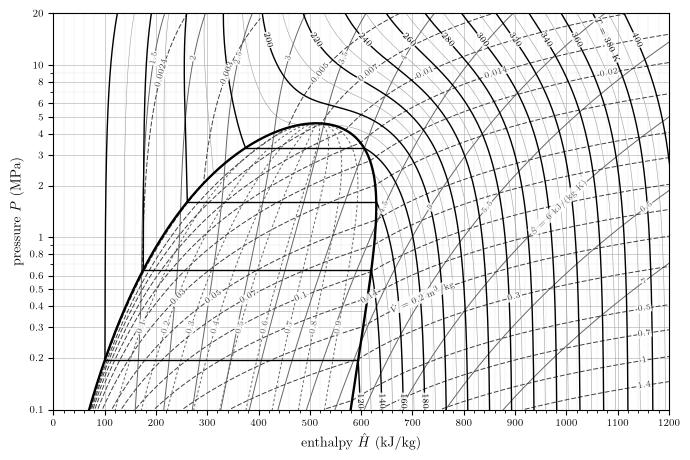

In [10]:
MET = dict(H_lim=(0, 1200), H_grid=100,
           isotherms=range(120, 401, 20), isotherms_minor=range(130, 391, 20),
           isentropes=[x/2 for x in range(3, 15)],
           volumes=(0.0024, 0.003, 0.005, 0.007, 0.01, 0.014, 0.02, 0.03, 0.05,
                    0.07, 0.1, 0.14, 0.2, 0.3, 0.5, 0.7, 1.0, 1.4),
           qualities=[i/10 for i in range(1, 10)],
           T_label_P=14, x_label_P=0.3,
           family_labels=[("T", 380, 14, "$T$ = 380 K"),
                          ("S", 6.0, 1.5, "$\\hat S$ = 6 kJ/(kg K)"),
                          ("V", 0.2, 0.45, "$\\hat V$ = 0.2 m$^3$/kg")])
MET["S_label_P"] = {s: (11 if s <= 4.0 else 1.5) for s in MET["isentropes"]}
MET["V_label_P"] = {v: (9 if v <= 0.02 else 0.45) for v in MET["volumes"]}

methane = Fluid("methane", **{k: v for k, v in FLUIDS["methane"].items() if k != "formula"})
fig, ax = plt.subplots(figsize=(7.0, 4.7))     # landscape, about half a page
ph_chart(ax, methane, **MET)
fig.tight_layout()
os.makedirs("pdf", exist_ok=True)
fig.savefig("pdf/Fig_3.3-2.pdf")               # the printed figure
plt.show()

## 6. Figure 3.3-3 &mdash; nitrogen

Same code, same five families, a different three constants and a different heat capacity. The
enthalpy axis is shorter because nitrogen's heat of vaporization is a quarter of methane's, and
the dome is lower because so is its critical point.

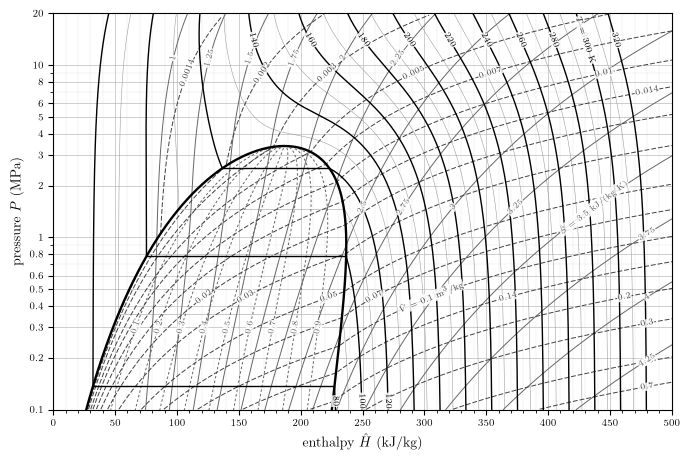

In [11]:
NIT = dict(H_lim=(0, 500), H_grid=50,
           isotherms=range(80, 321, 20), isotherms_minor=range(90, 311, 20),
           isentropes=[x/4 for x in range(4, 18)],
           volumes=(0.0014, 0.002, 0.003, 0.005, 0.007, 0.01, 0.014, 0.02, 0.03,
                    0.05, 0.07, 0.1, 0.14, 0.2, 0.3, 0.5, 0.7),
           qualities=[i/10 for i in range(1, 10)],
           T_label_P=14, x_label_P=0.3,
           family_labels=[("T", 300, 14, "$T$ = 300 K"),
                          ("S", 3.5, 1.5, "$\\hat S$ = 3.5 kJ/(kg K)"),
                          ("V", 0.1, 0.45, "$\\hat V$ = 0.1 m$^3$/kg")])
NIT["S_label_P"] = {s: (11 if s <= 2.25 else 1.5) for s in NIT["isentropes"]}
NIT["V_label_P"] = {v: (9 if v <= 0.014 else 0.45) for v in NIT["volumes"]}

nitrogen = Fluid("nitrogen", **{k: v for k, v in FLUIDS["nitrogen"].items() if k != "formula"})
fig, ax = plt.subplots(figsize=(7.0, 4.7))
ph_chart(ax, nitrogen, **NIT)
fig.tight_layout()
fig.savefig("pdf/Fig_3.3-3.pdf")               # the printed figure
plt.show()

## 7. Does it work? Illustration 6.5-1, on the nitrogen chart

Illustration 6.5-1 is where the text uses this figure, and it is a good test because it solves
the same problem three ways and compares them:

> Nitrogen is withdrawn from a 0.15 m$^3$ cylinder at 10 mol/min. The cylinder starts at 100 bar
> and 170 K, and is well enough insulated that the gas remaining in it expands **reversibly and
> adiabatically**. What are its temperature and pressure after 50 minutes, **(a)** treating the
> nitrogen as an ideal gas, **(b)** using the properties chart, **(c)** treating it as a van der
> Waals fluid?

Part (b) is two chart readings and a lever: find the initial state, follow the line of constant
entropy through it, and stop where the molar volume is the one the mass balance demands. The
cell below does exactly that, with the chart's own equation in place of a ruler.

In [12]:
from scipy.optimize import brentq

V1 = nitrogen.pr.molar_volume(170.0, 100e5, "vapor")     # m^3/mol at the start
N1 = 0.15/V1                                             # mol in the cylinder
N2 = N1 - 10*50                                          # after 50 min at 10 mol/min
V2 = 0.15/N2
S1 = nitrogen.S(170.0, 100e5, "vapor")

print(f"initially: V = {V1:.4e} m3/mol  ->  N = {N1:.1f} mol      [the book prints 1567.9]")
print(f"after 50 min: N = {N2:.1f} mol  ->  V = {V2:.4e} m3/mol")

T2 = brentq(lambda T: nitrogen.S(T, nitrogen.pr.pressure(V2, T), "vapor") - S1,
            120.0, 160.0, xtol=1e-8)
P2 = nitrogen.pr.pressure(V2, T2)
print(f"\nthis chart          T2 = {T2:5.1f} K   P2 = {P2/1e5:4.1f} bar")
print(f"the 5e, off Fig. 3.3-3   133 K        39 bar")
print(f"the 5e, ideal gas        129.6 K      40.3 bar")
print(f"the 5e, van der Waals    133.1 K      -")

initially: V = 9.5675e-05 m3/mol  ->  N = 1567.8 mol      [the book prints 1567.9]
after 50 min: N = 1067.8 mol  ->  V = 1.4047e-04 m3/mol

this chart          T2 = 136.4 K   P2 = 42.1 bar
the 5e, off Fig. 3.3-3   133 K        39 bar
the 5e, ideal gas        129.6 K      40.3 bar
the 5e, van der Waals    133.1 K      -


### The construction, drawn &mdash; art slot `c06uf002`

Illustration 6.5-1 does not only *read* Fig. 3.3-3, it **reprints a window of it** with the
construction marked. That window is the figure below, and it belongs here rather than in a
chapter 6 notebook: it is Fig. 3.3-3 magnified, so it should come from the same code and move
whenever the chart moves.

Two things it does that the original could not. The states are **computed rather than traced**
&mdash; *i* and *f* land on the curves by construction, not by a draughtsman's eye &mdash; and
each label sits **on** its own curve carrying its own units. That frees the margins the 5e
needed for leader lines, so the frame is 40 % wider inside the same footprint on the page.

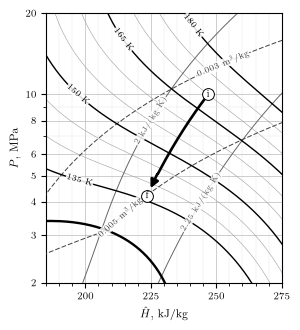

In [13]:
# --- the construction, as Illustration 6.5-1 reprints it -------------------
# ART SLOT c06uf002. Trim matches the footprint the 5e original occupies on book
# p. 248 -- 3.1 x 3.4 in -- so it drops into the same hole.
INSET = dict(
    H_lim=(185, 275), P_lim=(2, 20), H_grid=25, H_minors=5,
    isotherms=(135, 150, 165, 180),
    isotherms_minor=(140, 145, 155, 160, 170, 175),
    isentropes=(2.0, 2.25), volumes=(0.003, 0.005),
    # Label heights come from where the curves actually are, not from the eye: with
    # units attached each label is three times longer than a bare number, and the
    # top-right corner will not hold three of them.
    T_label_P={135: 4.8, 150: 10, 165: 16, 180: 18},
    S_label_P={2.0: 8, 2.25: 4},
    V_label_P={0.003: 13, 0.005: 3.5},
    label_fmt={"T": "{:g} K", "S": "{:g} kJ/(kg K)", "V": "{:g} m$^3$/kg"},
    mark_critical=False)

MARKER_MS = 8.5                                  # points, the i and f circles
H_i, H_f = nitrogen.H(170.0, 100e5, "vapor"), nitrogen.H(T2, P2, "vapor")

fig, ax = plt.subplots(figsize=(3.1, 3.4))
ph_chart(ax, nitrogen, **INSET)

Hs, Ps = isentrope(nitrogen, S1, INSET["P_lim"], n=600)
seg = (Ps <= 10.0 + 1e-9) & (Ps >= P2/1e6 - 1e-9)
hs, ps = Hs[seg], Ps[seg]
o = np.argsort(-ps)                              # i first, f last
hs, ps = hs[o], ps[o]


def _back_off(xy_end, xy_prev, points):
    """xy_end pulled `points` back toward xy_prev, measured on the page.

    arrowprops' own shrinkB is not reliable on a logarithmic axis -- the gap it
    leaves is not the gap asked for. Converting to display coordinates and back is
    exact, and it is what keeps the arrowhead off the rim of the marker rather than
    on top of it.
    """
    (x1, y1), (x0, y0) = (ax.transData.transform(xy_end),
                          ax.transData.transform(xy_prev))
    dx, dy = x1 - x0, y1 - y0
    n = np.hypot(dx, dy) or 1.0
    px = points*fig.dpi/72.0
    return ax.transData.inverted().transform((x1 - dx/n*px, y1 - dy/n*px))


# Both ends of the head come off the SAME tangent at f. Taking the tail from the
# point list instead does not work: the isentrope is ~225 points over this stretch,
# so hs[-8] lands nearer f than the backed-off tip does and the arrow comes out
# reversed and headless.
def _tangent(points):
    return _back_off((hs[-1], ps[-1]), (hs[-2], ps[-2]), points)


tip, tail = _tangent(MARKER_MS/2 + 1.5), _tangent(MARKER_MS/2 + 12.5)
keep = ps > tail[1]                              # curve stops where the head starts
ax.plot(np.append(hs[keep], tail[0]), np.append(ps[keep], tail[1]),
        "-", color="k", lw=1.9, zorder=7, solid_capstyle="round")
ax.annotate("", xy=tip, xytext=tail, zorder=7,
            arrowprops=dict(arrowstyle="-|>", color="k", lw=1.9,
                            mutation_scale=12, shrinkA=0, shrinkB=0))
for H, P, lab in ((H_i, 10.0, "i"), (H_f, P2/1e6, "f")):
    ax.plot([H], [P], "o", mfc="white", mec="k", mew=0.7, ms=MARKER_MS, zorder=8)
    ax.text(H, P, lab, fontsize=7, ha="center", va="center", zorder=9, style="italic")

ax.set_xlabel(r"$\hat H$, kJ/kg", fontsize=8)
ax.set_ylabel(r"$P$, MPa", fontsize=8)
fig.tight_layout()
fig.savefig("pdf/c06uf002.pdf")                  # the printed inset
plt.show()

## 8. Figure 5.1-3 &mdash; the liquefaction path, for Illustration 5.1-1

Chapter 5's Illustration 5.1-1 liquefies natural gas, and works the whole thing off this
chart: *"one follows a line of constant entropy in Fig. 3.3-2, which is redrawn here with all
the stages indicated."* That redrawing is **Figure 5.1-3**, and it lives here for the same
reason the Illustration 6.5-1 inset does &mdash; it is Fig. 3.3-2 with a path on it, so it has
to move when the chart moves.

The path is seven legs: three compressor stages, each following a line of constant entropy;
two intercoolers and a final cooler, each isobaric; and the Joule&ndash;Thomson expansion,
which is vertical because throttling is isenthalpic. It ends **inside the dome**, and where it
lands between the two saturation curves is what part (b) asks for.

**What is drawn here is sparser than Fig. 3.3-2.** Constant-volume lines appear nowhere in the
illustration, so they are gone, and the isentropes are left light and unlabeled &mdash; the
three compressor legs *are* isentropes, and a labeled family running beside them invites
reading the path off the wrong curve. What remains is what the illustration reads: isotherms,
the dome, and quality.

stage 1:   1 ->   5 bar   Hhat  936.9 -> 1218.1 kJ/kg   T_out 401.0 K   work 281.2 kJ/kg
stage 2:   5 ->  25 bar   Hhat  931.9 -> 1210.4 kJ/kg   T_out 403.2 K   work 278.5 kJ/kg
stage 3:  25 -> 100 bar   Hhat  906.4 -> 1130.3 kJ/kg   T_out 390.5 K   work 223.9 kJ/kg

total compressor work  783.6 kJ/kg          [the 5e reads 722]
after the throttle: Hhat = 495.2 kJ/kg, and at 1 bar the dome runs 69.9 to 579.6
so the vapor fraction is 0.834 and 0.166 of the feed liquefies  [the 5e reads 0.826 / 0.174]


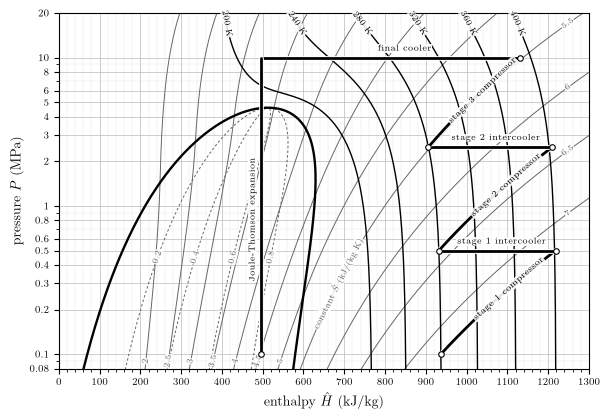

In [40]:
# --- Figure 5.1-3: Illustration 5.1-1's path on the methane chart ----------
import matplotlib.patheffects as pe

T_at_SP = lambda S, P, lo=100., hi=900.: brentq(
    lambda t: methane.S(t, P, "vapor") - S, lo, hi, xtol=1e-9)

STAGES = ((1e5, 5e5), (5e5, 25e5), (25e5, 100e5))   # the three compressor stages
legs, nodes = [], []
for k, (Pin, Pout) in enumerate(STAGES, 1):
    H_in, S_in = methane.H(280., Pin, "vapor"), methane.S(280., Pin, "vapor")
    T_out = T_at_SP(S_in, Pout)
    H_out = methane.H(T_out, Pout, "vapor")
    Pg = np.geomspace(Pin, Pout, 140)
    legs.append((f"stage {k} compressor",
                 np.array([methane.H(T_at_SP(S_in, p), p, "vapor") for p in Pg]), Pg/1e6))
    nodes += [(H_in, Pin/1e6), (H_out, Pout/1e6)]
    T_end = 280. if Pout < 100e5 else 210.          # the last cooler goes to 210 K
    Tg = np.linspace(T_out, T_end, 140)
    legs.append((f"stage {k} intercooler" if Pout < 100e5 else "final cooler",
                 np.array([methane.H(t, Pout, "vapor") for t in Tg]),
                 np.full_like(Tg, Pout/1e6)))
    print(f"stage {k}: {Pin/1e5:3g} -> {Pout/1e5:3g} bar   "
          f"Hhat {H_in:6.1f} -> {H_out:6.1f} kJ/kg   T_out {T_out:5.1f} K   "
          f"work {H_out - H_in:5.1f} kJ/kg")
W = sum(l[1][-1] - l[1][0] for l in legs if "compressor" in l[0])

H_jt = methane.H(210., 100e5, "vapor")              # throttling is isenthalpic
# Geometrically two points would do -- it is a straight vertical line -- but
# leg_label picks a plotted point, so give it points to pick from. Geometric
# spacing because the pressure axis is logarithmic.
legs.append(("Joule-Thomson expansion",
             np.full(120, H_jt), np.geomspace(10.0, 0.1, 120)))
nodes.append((H_jt, 0.1))
T_1bar = brentq(lambda t: methane.Psat(t) - 1e5, 95., methane.Tc*0.99)
_, HL, HV, *_ = methane.sat(T_1bar)
x = (H_jt - HL)/(HV - HL)                           # the flash drum
print(f"\ntotal compressor work  {W:.1f} kJ/kg          [the 5e reads 722]")
print(f"after the throttle: Hhat = {H_jt:.1f} kJ/kg, and at 1 bar the dome runs "
      f"{HL:.1f} to {HV:.1f}")
print(f"so the vapor fraction is {x:.3f} and {1-x:.3f} of the feed liquefies  "
      f"[the 5e reads 0.826 / 0.174]")

# The frame is WIDER than Fig. 3.3-2's. Two compressor stages now end at 1218 and
# 1210 kJ/kg, past the 1200 the parent chart stops at, and the corner where each
# compressor meets its intercooler is the thing this figure exists to show. (The 5e
# read 1195 and 1180 off its chart, which just fitted.) The floor is dropped from
# 0.1 to 0.08 MPa for the same reason: two states sit exactly at 1 bar and would
# otherwise be cut in half by the axis.
MET513 = dict(H_lim=(0, 1300), P_lim=(0.08, 20), H_grid=100,
              isotherms=(200, 240, 280, 320, 360, 400), isotherms_minor=(),
              isentropes=[2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0, 5.5, 6.0, 6.5, 7.0], volumes=(),
              qualities=(0.2, 0.4, 0.6, 0.8),
              T_label_P=17, x_label_P=0.45, S_label_P={},
              label_fmt={"T": "{:g} K"},
              family_labels=[("S", 5.5, 0.30, "constant $\\hat S$ (kJ/(kg K)")])

fig, ax = plt.subplots(figsize=(6.2, 4.3))
ph_chart(ax, methane, **MET513)
HALO = [pe.withStroke(linewidth=3.4, foreground="white")]   # the path over the chart
for _, H, P in legs:
    ax.plot(H, P, "-", color="k", lw=2.0, zorder=7, path_effects=HALO,
            solid_capstyle="round", solid_joinstyle="round")
for H, P in nodes:
    ax.plot([H], [P], "o", mfc="white", mec="k", mew=0.8, ms=4.0, zorder=8)


def leg_label(name, frac, dx=0, dy=0.0, size=5.8, rot=None):
    """Write a leg's own name along it.

    frac  where along the leg: 0 at its start, 1 at its end. It selects one of the
          leg's PLOTTED POINTS, so a leg drawn with only two of them can only ever
          be labeled at one end or the other -- hence the assert.
    dx    shift in enthalpy, kJ/kg, added. The x axis is linear.
    dy    shift in pressure, as a FRACTION of it: P*(1 + dy). The y axis is
          logarithmic, so one value gives the same visual gap at any pressure --
          which is why 0.34 lifts all three horizontal legs equally clear of their
          own lines. Use dy = 0 to put the text on the line and break it, the way
          the compressor labels and the chart's own curve labels do.
    rot   None follows the curve's tangent there; a number overrides it.
    """
    H, P = next((h, p) for n, h, p in legs if n == name)
    assert len(H) > 2, f"{name!r} is drawn with {len(H)} points, so frac cannot " \
                       f"place a label along it -- give the leg more points"
    i = int(frac*(len(H) - 1))
    a = _angle(ax, H, P, min(max(i, 1), len(H) - 2)) if rot is None else rot
    ax.text(H[i] + dx, P[i]*(1 + dy), name, fontsize=size, ha="center", va="center",
            rotation=a, rotation_mode="anchor", zorder=9,
            bbox=dict(fc="white", ec="none", pad=0.6, alpha=0.9))


for k in (1, 2, 3):
    leg_label(f"stage {k} compressor", 0.64)
leg_label("stage 1 intercooler", 0.45, dy=0.15, rot=0)
leg_label("stage 2 intercooler", 0.45, dy=0.15, rot=0)
leg_label("final cooler", 0.55, dy=0.15, rot=0)
leg_label("Joule-Thomson expansion", 0.55, dx=-20, rot=90)   # ~2.6 MPa
fig.tight_layout()
fig.savefig("pdf/Fig_5.1-3.pdf")                    # the printed figure
plt.show()

### Does it agree with anything? Illustration 5.1-1 against the book's own Aspen run

The illustration carries an **Aspen Plus Peng-Robinson simulation** of parts (a) and (b)
(*Aspen Illustrations > Chapter 5 > 5.1-1a+b*), and the 5e prints its output. That makes three
numbers to check against, and they are the right three: the chart here *is* Peng-Robinson, so it
should land on Aspen, not on the values the 5e read off the licensed chart by hand.

The cell below also works **part (c), the Linde process**, which is not just part (a) with a
different denominator: the Linde compressor is fed the **cold recycle mixed with fresh make-up**,
not the 280 K feed, so its first stage does much less work.

And it computes the **ideal-gas** work for each stage, which is the check that decides the one
disagreement. Stages 1 and 2 compress the *same ratio* from the *same inlet temperature*, so for
an ideal gas their work is identical and any real-gas correction is a couple of percent. Whatever
disagrees with that is wrong, whoever printed it.

In [15]:
# --- Illustration 5.1-1 checked against Aspen, and part (c) worked ---------
def _stage(Tin, Pin, Pout):
    """(work kJ/kg, outlet T) for one reversible adiabatic compressor stage."""
    T_out = T_at_SP(methane.S(Tin, Pin, "vapor"), Pout)
    return methane.H(T_out, Pout, "vapor") - methane.H(Tin, Pin, "vapor"), T_out


# the same stage, for an IDEAL gas, using this chart's own Cp*
_cp, _M = methane.cp, methane.M
_Hig = lambda T: sum(c*T**(i + 1)/(i + 1) for i, c in enumerate(_cp))/_M   # J/mol / (g/mol) = kJ/kg
_Sig = lambda T, P: (sum(c*T**i/i if i else c*np.log(T) for i, c in enumerate(_cp))
                     - R*np.log(P/PREF))/_M


def _stage_ig(Tin, Pin, Pout):
    T_out = brentq(lambda t: _Sig(t, Pout) - _Sig(Tin, Pin), 150., 900.)
    return _Hig(T_out) - _Hig(Tin), T_out


ASPEN = (281.3, 260.6, 224.0)          # the 5e's printed Aspen PR output
CHART = (255.0, 242.0, 225.0)          # what the 5e read off the licensed chart
print(f"{'stage':<22}{'ideal gas':>11}{'this chart':>12}{'5e Aspen PR':>13}{'5e chart':>10}")
for k, (Pin, Pout) in enumerate(STAGES, 1):
    w, _ = _stage(280., Pin, Pout)
    w_ig, _ = _stage_ig(280., Pin, Pout)
    print(f"{k}: {Pin/1e5:g} -> {Pout/1e5:g} bar" .ljust(22)
          + f"{w_ig:11.1f}{w:12.1f}{ASPEN[k-1]:13.1f}{CHART[k-1]:10.1f}")
print(" total".ljust(22) + f"{'':11}{W:12.1f}{sum(ASPEN):13.1f}{sum(CHART):10.1f}")
print(f" liquefied fraction".ljust(22) + f"{'':11}{1-x:12.3f}{0.164:13.3f}{0.174:10.3f}")

print("\nStages 1 and 3 sit on Aspen to 0.04 %, and so does the liquefied fraction.")
print("Stage 2 does not -- and stage 2 is the one that CANNOT differ from stage 1 by much:")
print("same pressure ratio, same 280 K inlet, so the ideal gas gives them identical work.")
_f = lambda T: _stage(T, 5e5, 25e5)[0] - ASPEN[1]
_g = lambda P: _stage(280., 5e5, P)[0] - ASPEN[1]
print(f"  reproducing Aspen's 260.6 needs an inlet of {brentq(_f, 200., 300.):.1f} K "
      f"or a discharge of {brentq(_g, 6e5, 25e5)/1e5:.1f} bar;")
print("  the problem statement says 280 K and 25 bar. Suspect the second intercooler in the"
      " flowsheet.")

# --- part (c): the Linde process -------------------------------------------
H_recycle = methane.H(200., 1e5, "vapor")        # recycle leaves the exchanger at 1 bar, 200 K
H_fresh = methane.H(280., 1e5, "vapor")
omega = (H_jt - HL)/(H_recycle - HL)             # mass fraction recycled
H_mix = omega*H_recycle + (1 - omega)*H_fresh    # what the compressor actually sees
T_mix = brentq(lambda t: methane.H(t, 1e5, "vapor") - H_mix, 150., 300.)
W1_L, T1_L = _stage(T_mix, 1e5, 5e5)
W2_L, W3_L = _stage(280., 5e5, 25e5)[0], _stage(280., 25e5, 100e5)[0]
W_L = W1_L + W2_L + W3_L

print("\n--- part (c), the Linde process ---")
print(f"  recycle fraction {omega:.3f}, so {1-omega:.3f} liquefies      [the 5e reads 0.604 / 0.396]")
print(f"  compressor inlet is the MIXED stream: {H_mix:.1f} kJ/kg at {T_mix:.1f} K"
      f"   [the 5e reads 837 at 233 K]")
print(f"  stage 1 from there: {W1_L:.1f} kJ/kg, out at {T1_L:.1f} K"
      f"        [the 5e reads 183 kJ/kg at 388 K --")
print(f"      388 K is the part-(a) outlet, from an inlet 47 K warmer; it cannot also be this one]")
print(f"  total {W_L:.1f} kJ/kg -> {W_L/(1-omega):.0f} kJ per kg LNG      [the 5e reads 650 -> 1641]")
print(f"  simple process, for comparison: {W/(1-x):.0f} kJ per kg LNG    [the 5e reads 4149]")
print(f"\n  Linde advantage {(W/(1-x))/(W_L/(1-omega)):.2f}x   [the 5e gets 2.53x] -- the Comment's"
      f" \"about 40 percent\" still holds")

stage                   ideal gas  this chart  5e Aspen PR  5e chart
1: 1 -> 5 bar               282.0       281.2        281.3     255.0
2: 5 -> 25 bar              282.0       278.5        260.6     242.0
3: 25 -> 100 bar            236.7       223.9        224.0     225.0
 total                                  783.6        765.9     722.0
 liquefied fraction                     0.166        0.164     0.174

Stages 1 and 3 sit on Aspen to 0.04 %, and so does the liquefied fraction.
Stage 2 does not -- and stage 2 is the one that CANNOT differ from stage 1 by much:
same pressure ratio, same 280 K inlet, so the ideal gas gives them identical work.
  reproducing Aspen's 260.6 needs an inlet of 261.9 K or a discharge of 22.9 bar;
  the problem statement says 280 K and 25 bar. Suspect the second intercooler in the flowsheet.

--- part (c), the Linde process ---
  recycle fraction 0.611, so 0.389 liquefies      [the 5e reads 0.604 / 0.396]
  compressor inlet is the MIXED stream: 832.4 kJ/

The initial charge, **1567.8 mol against the 1567.9 the text prints**, is the check that matters
most: it is one molar volume read at 100 bar and 170 K, and it says the equation of state and the
book agree on where this problem starts.

The answer moves, though. This chart gives **136.4 K and 42.1 bar** where the 5e read 133 K and
39 bar off the licensed chart &mdash; about 3 K and 3 bar. The recomputed value is the more
consistent one: it uses the same equation of state and the same heat capacity as everything else
in the 6e, whereas the printed answer combined a reference-quality chart with a two-term
$C_P^{*}$ whose errors happened to run the other way. **The printed answers in Illustration 6.5-1
change with this figure**, which the author has accepted.

The illustration's point survives intact, and is arguably sharper: the ideal gas is wrong by
7 K, and both real-fluid routes agree with each other to about 3 K.

## What this notebook shows

- **A property chart can be derived.** Three constants, four heat-capacity
  coefficients and one cubic equation put every curve on these two pages. Nothing was measured here that is not already in the book.
- **Check the equation before you draw 300 curves with it.** The book's own Wagner constants are an independent referee for the saturation line, and they cost nothing to consult.
- **Know which axis forgives what.** The 4.8 % error in pressure is invisible on a logarithmic axis and would be glaring on a linear one; a 12 % error in liquid volume is invisible *except* on the one family that plots volume. Accuracy is a property of the reading, not of the number.
- **A correlation outside its range can be worse than no correlation.** Appendix A.II's methane row for 298-1800K is not merely inaccurate at 100 K, it is below a floor that no molecule can go under. Knowing the limit &mdash; $4R$ for a nonlinear molecule &mdash; is what makes that visible.

## Your turn

1. **Read Illustration 5.1-1 off the methane chart.** It liquefies natural gas from 1 bar and
   280 K by compressing it in stages, following a line of constant entropy through each. Plot the
   path on your chart and get the work per kilogram. How much does the answer change if the
   compressors are 75 % efficient rather than reversible?
2. **Find the inversion curve.** A Joule&ndash;Thomson expansion is horizontal on this chart, so
   the fluid cools only where an isotherm slopes the right way. Locate, for methane, the pressure
   above which throttling from 300 K *heats* the gas. Then check nitrogen. Why does the Linde
   process work at all?
3. **Put the two fluids on one pair of axes** in reduced coordinates &mdash; $P/P_c$ against
   $(\hat H - \hat H_c)/(RT_c/M)$. How close do methane and nitrogen come to superimposing?
   That is the principle of corresponding states (&sect;6.6) as a picture rather than a claim.
4. **Break the heat capacity on purpose.** Redraw Fig. 3.3-2 with `cp_A2_printed` in place of the
   cryogenic row. The dome barely moves and the isotherms slide sideways &mdash; why should an
   error in the *ideal-gas* heat capacity leave the saturation line nearly alone?
5. **Test the liquid volumes.** The compressed-liquid $\hat V$ curves are the weak family. Using
   `Lden` and `Tden` from `pure_property.csv`, work out how far the 0.0014 m$^3$/kg curve is
   misplaced for nitrogen, and decide whether you would print it.
6. **Add a family the original has and this one does not**: lines of constant Joule&ndash;Thomson
   coefficient, or the saturated-solid line below the triple point. What data would each need?